# Pretraining on unlabeled data


In [104]:
import importnb
with importnb.Notebook():
    from chapter4 import GPTModel

GPT_CONFIG_124m = {
    "vocab_size": 50_257,   # number of unique token IDs the tokenizer/model supports
    "context_length": 256, # maximum number of tokens the model can process at once
    "emb_dim": 768,         # size of each token and postional embedding
    "n_heads": 12,          # number of attention heads in each multi-head attention layer
    "n_layers": 12,         # number of transformer blocks stacked in the model
    "drop_rate": 0.1,       # dropout probability used for regularization
    "qkv_bias": False,      # whether query/key/value linear layers use bias terms.
}

In [7]:
import torch
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124m)

In [8]:
# import gc
# del model
# gc.collect()

In [13]:
import tiktoken

def generate_text_simple(model, idx, max_new_tokens, context_size): 
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1 )
    return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model, 
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124m["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you dialect Suggestlikesurface holidays Hurricanes universal investigativeUnix Funny


In [14]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]
targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [17]:
import torch 
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token ids:\n", token_ids)

Token ids:
 tensor([[[32063],
         [13866],
         [22805]],

        [[37429],
         [29669],
         [27596]]])


In [20]:
print(f"Targets batch 1: {token_ids_to_text(targets[0],tokenizer)}")
print(f"Outputs batch 1: \n {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1: 
  blendedbagefinder


In [33]:
torch.set_printoptions(sci_mode=False)
text_id = 0
target_probas_1 = probas[text_id, [0,1,2], targets[text_id]]
print(target_probas_1)
text_idx = 1
target_probas_2 = probas[text_idx, [0,1,2], targets[text_idx]]
print(target_probas_2)


tensor([    0.0000,     0.0000,     0.0000])
tensor([    0.0000,     0.0001,     0.0000])


In [34]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([-10.1077, -10.3127, -11.4374, -10.8923,  -9.1719, -12.0331])


In [37]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.6592)


In [38]:
negative_avg_log_probas = avg_log_probas * -1

In [40]:
print(negative_avg_log_probas)

tensor(10.6592)


In [42]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [46]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])
tensor(10.6592)


In [48]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(42582.3438)


In [49]:
file_path = "training_text.txt"
with open(file_path, "r", encoding="utf8") as f:
    text_data = f.read()


In [50]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [51]:
import importnb
with importnb.Notebook(include_non_defs=False):
    from chapter2 import create_dataloader_v1

In [57]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [58]:
torch.manual_seed(123)
train_loader =  create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124m["context_length"],
    stride=GPT_CONFIG_124m["context_length"],
    drop_last=True,
    suffle=True,
    num_workers=0
)

val_loader =  create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124m["context_length"],
    stride=GPT_CONFIG_124m["context_length"],
    drop_last=True,
    suffle=True,
    num_workers=0
)

256 256
256 256


In [60]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\n Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

 Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [61]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss


In [64]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches



In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f"Training loss: {train_loss}")
print(f"Validation loss: {val_loss}")

Training loss: 10.980808364020454
Validation loss: 10.993600845336914


In [66]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [96]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()


In [94]:
def training_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    for epoch in range(num_epochs):
        model.train() # prepare the model for training 1
        # loop over each training set
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch + 1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f},"
                      f"Val loss {val_loss:.3f}"
                )
        
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen




In [73]:
import gc
def delete_and_clean(variable_name: str, scop_dict: dict):
    if variable_name in scop_dict:
        del scop_dict[variable_name]
        gc.collect()
        print(f"{variable_name} has been deleted")
    else:
        print(f"{variable_name} not found")


In [83]:
delete_and_clean("model", locals())
delete_and_clean("model", globals())

model has been deleted
model not found


In [84]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124m)

In [85]:
print(device)

cpu


In [97]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epochs = 10
train_losses, val_losses, tokens_seen = training_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=5, eval_iter=5, start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 6.763,Val loss 7.254
Ep 1 (Step 000005): Train loss 5.944,Val loss 6.777
Every effort moves you.                                                 
Ep 2 (Step 000010): Train loss 5.843,Val loss 6.575
Ep 2 (Step 000015): Train loss 5.263,Val loss 6.589
Every effort moves you of the, and I had been.     "I, and, I had, and the, I had been, and the, and the, and, and the, I had the, and the, and I had the
Ep 3 (Step 000020): Train loss 4.898,Val loss 6.403
Ep 3 (Step 000025): Train loss 4.344,Val loss 6.277
Every effort moves you. It was, and I was. Gisburn's the picture. I had been, I was, I was, and I had been. Gisburn's "I had been. Gisburn, and I had been. Gis
Ep 4 (Step 000030): Train loss 3.699,Val loss 6.153
Ep 4 (Step 000035): Train loss 3.146,Val loss 6.153
Every effort moves you know he was not to the fact of the fact the fact of the fact of the fact of the fact of the fact, and that, in the fact of the fact-c.         "I had been
Ep 5 (Step 000040):

# Decoding strategies to control randomness

In [101]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeaddAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.5, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeaddAttention(
        (W_query): Linear(in_featur

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [144]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124m["context_length"]
)
print(f"Output text:\n {token_ids_to_text(token_ids, tokenizer)}")

Output text:
 Every effort moves you?"

"Yes--quite insensible to the fact with equanimity.
"--had lent herself in an


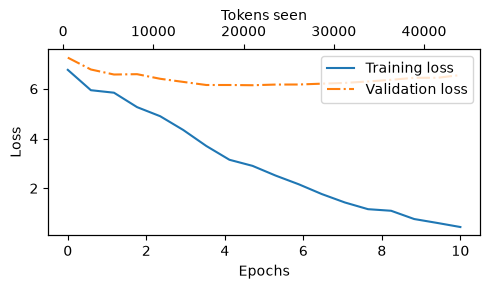

In [147]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [157]:
# temperature scaling
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8    
}

In [115]:
inverse_vocab = { v: k for k, v in vocab.items()}

In [126]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [151]:
probas =  torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])


forward


In [152]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


In [158]:
def print_sample_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sample_ids = torch.bincount(torch.tensor(sample))    
    for x, freq in enumerate(sample_ids):
        print(f"{freq} x {inverse_vocab[x]}")

print_sample_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


In [159]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

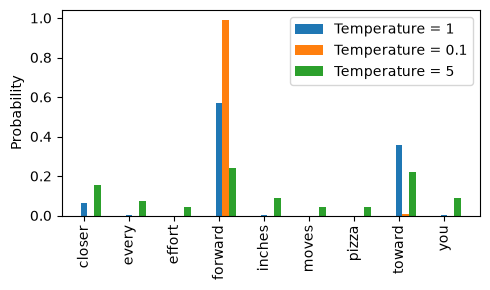

In [164]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax =  plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f"Temperature = {T}")    
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()


In [165]:
top_k = 3
top_logits, top_pos =  torch.topk(next_token_logits, top_k)
print(f"Top logits: {top_logits}")
print(f"Top positions: {top_pos}")

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [166]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float('-inf')),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [167]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [174]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        # even when we usually pass one user prompt, the function handles mutiple prompts at once
        # also we keep the last context_size tokens 
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        # this means give me all the batches, 
        # but only the last logits for each batchs in the current sequence
        logits = logits[:, -1, :]
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits <  min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:
            logits = logits / temperature
            probs =  torch.softmax(logits, dim=-1)
            # returns the token with the probability that is hightest after applying the temperature and softmax function.
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


In [178]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124m["context_length"],
    top_k=5,
    temperature=1.4
)
print(f"Output text:\n {token_ids_to_text(token_ids, tokenizer)}")

Output text:
 Every effort moves you know without bitterness, with a one of the face the irony. She wanted
